# Spin-null sensitivity: D99 vs equal-area parcellation


In [ ]:
from pathlib import Path

ROOT = Path.cwd().parents[0]

MAC_DIR    = ROOT / 'data' / 'gifti' / 'CIVET_macaque-alpha-0.2'
LH_LABEL   = MAC_DIR / 'D99_atlas_rsl_sym_left.label.gii'
MID_L      = MAC_DIR / 'macaque_mid_mc_left.surf.gii'
SPHERE_L   = MAC_DIR / 'sphere_left_iso.surf.gii'
UNIF_LABEL = ROOT / 'data' / 'gifti' / 'equal_area_atlas_left.label.gii'
LABEL_CSV  = ROOT / 'data' / 'd99_to_yeo_network_labels.csv'

ID_COL, ABBR_COL = 'D99', 'D99_abbr'
EXCLUDE = (70,)      # label ids dropped besides background
N_PERM  = 5000
SEED    = 17
ALPHA   = 0.05

In [ ]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy import sparse
from sklearn.neighbors import NearestNeighbors
from netneurotools import stats as nnstats
from neuromaps.nulls.spins import get_parcel_centroids

from nilearn import plotting
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def make_contiguous(path_in, path_out, start=1, exclude=()):
    """Relabel a label.gii to contiguous ids, dropping background (0) and `exclude`."""
    g   = nib.load(path_in)
    lab = g.darrays[0].data.astype(int)
    old = np.unique(lab[(lab > 0) & ~np.isin(lab, list(exclude))])
    new = np.zeros_like(lab)
    for i, o in enumerate(old):
        new[lab == o] = start + i
    g.darrays[0].data = new.astype(g.darrays[0].data.dtype)
    nib.save(g, path_out)
    return list(old), new

## D99: contiguous ids, centroids, sizes

In [ ]:
contig_path = f'{MAC_DIR}/_d99_lh_contig.label.gii'
old_ids, lab_lh = make_contiguous(LH_LABEL, contig_path, start=1, exclude=EXCLUDE)
N             = len(old_ids)
contig_to_d99 = {k + 1: d for k, d in enumerate(old_ids)}
d99_to_contig = {d: k + 1 for k, d in enumerate(old_ids)}
sizes         = np.array([(lab_lh == k).sum() for k in range(1, N + 1)])
chance        = 1.0 / N

centroids, hemiid = get_parcel_centroids([SPHERE_L], parcellation=[contig_path],
                                         method='geodesic')
assert centroids.shape[0] == N
print(f'D99: {N} parcels; centroids {centroids.shape}; size CV={sizes.std()/sizes.mean():.2f}')

D99: 140 parcels; centroids (140, 3); size CV=2.06


## Equal-area atlas: loaded from file

In [ ]:
# Load the provided equal-area parcellation (same surface / background / N as D99).
lab_unif = nib.load(f'{MAC_DIR}/_d99_lh_uniform.label.gii').darrays[0].data.astype(int)
assert lab_unif.shape == lab_lh.shape, 'vertex count differs from D99'
assert np.array_equal(lab_unif == 0, lab_lh == 0), 'background differs from D99'

present = np.unique(lab_unif[lab_unif > 0])
N_u     = len(present)
assert np.array_equal(present, np.arange(1, N_u + 1)), 'equal-area ids not contiguous 1..N'
sizes_u = np.array([(lab_unif == k).sum() for k in range(1, N_u + 1)])

centroids_u, hemiid_u = get_parcel_centroids([SPHERE_L], parcellation=[UNIF_LABEL],
                                             method='geodesic')
assert centroids_u.shape[0] == N_u
print(f'equal-area: {N_u} parcels; size CV={sizes_u.std()/sizes_u.mean():.2f} '
      f'(D99 {sizes.std()/sizes.mean():.2f})')

equal-area: 140 parcels; size CV=0.06 (D99 2.06)


## Hungarian self-assignment, size, and crowding

In [56]:
# Hungarian spin assignments (reused below for the simulation), then per-parcel self-rate.
idx_real_h = nnstats.gen_spinsamples(centroids,   hemiid,   n_rotate=N_PERM,
                                     method='hungarian', seed=SEED)
idx_unif_h = nnstats.gen_spinsamples(centroids_u, hemiid_u, n_rotate=N_PERM,
                                     method='hungarian', seed=SEED)
self_rate   = (idx_real_h == np.arange(N)[:, None]).mean(1)
self_rate_u = (idx_unif_h == np.arange(N_u)[:, None]).mean(1)

def crowding(C, k=10):
    d, _ = NearestNeighbors(n_neighbors=k + 1).fit(C).kneighbors(C)
    return d[:, 1:].mean(1)                # smaller = more crowded
crowd, crowd_u = crowding(centroids), crowding(centroids_u)
worst = np.argsort(self_rate)[::-1][:12]  # crowded paralimbic cluster

rs_size,  ps_size  = spearmanr(sizes, self_rate)
rc_crowd, pc_crowd = spearmanr(crowd, self_rate)
print(f'D99 Hungarian self-rate ~ size    : rho={rs_size:+.2f} (p={ps_size:.1e})')
print(f'D99 Hungarian self-rate ~ crowding: rho={rc_crowd:+.2f} (p={pc_crowd:.1e})')

D99 Hungarian self-rate ~ size    : rho=-0.08 (p=3.3e-01)
D99 Hungarian self-rate ~ crowding: rho=-0.35 (p=2.0e-05)


## 1. Parcellations on the cortical surface

/var/folders/r7/dfxvf5_d7m57v2c52lgnxm780000gn/T/ipykernel_47457/1774756895.py:13: DeprecationWarning:

The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None



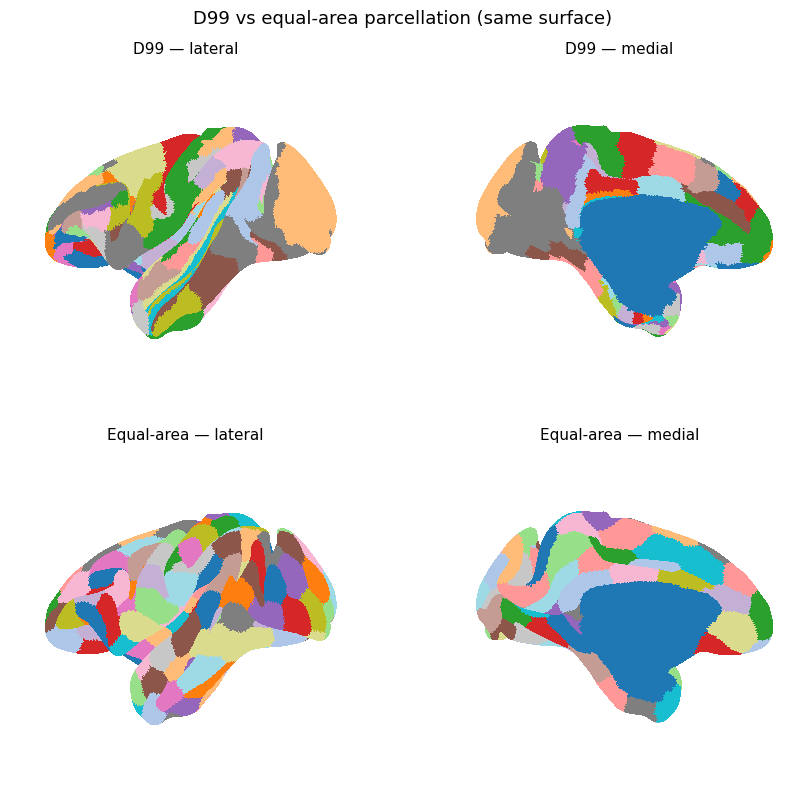

In [ ]:


surf = nib.load(MID_L)
mesh = [surf.darrays[0].data, surf.darrays[1].data]
views = ['lateral', 'medial']

try:
    fig, axes = plt.subplots(2, len(views), figsize=(4.6 * len(views), 8.2),
                             subplot_kw={'projection': '3d'})
    for r, (parc, name) in enumerate([(lab_lh, 'D99'), (lab_unif, 'Equal-area')]):
        for c, v in enumerate(views):
            ax = axes[r, c]
            plotting.plot_surf_roi(mesh, roi_map=parc.astype(float), hemi='left',
                                   view=v, cmap='tab20', axes=ax, figure=fig,
                                   colorbar=False)
            ax.set_title(f'{name} — {v}', fontsize=11)
    fig.suptitle('D99 vs equal-area parcellation (same surface)', fontsize=13)
    fig.tight_layout()
    plt.show()
except Exception as e:
    print(f'surface render skipped ({type(e).__name__}: {e}); '
          f'try an inflated surface or a single view.')

## 2–3. Self-assignment vs size and crowding

Under the Hungarian null, D99 self-assignment is **flat in parcel size** but **rises sharply
with centroid crowding**; the worst-permuted parcels (orange) form the crowded ventral/anterior
paralimbic cluster. The equal-area atlas is flat on both axes — the same spin machinery, no bias.

In [ ]:


GREY, BLUE, ORANGE = 'rgb(115,115,115)', '#3a7ca5', '#e8842a'
sr, sru = self_rate * 100, self_rate_u * 100
rs_u = spearmanr(sizes_u, self_rate_u)[0]
rc_u = spearmanr(crowd_u, self_rate_u)[0]

_AX = dict(showline=True, linecolor='black', linewidth=1.2, mirror=True,
           ticks='outside', tickcolor='black', ticklen=4,
           showgrid=True, gridcolor='#ececec', zeroline=False,
           tickfont=dict(family='Helvetica', size=11, color='black'),
           title_font=dict(family='Helvetica', size=12, color='black'))

fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.12)

def _panel(xr, xu, xw, showleg):
    return [
        go.Scatter(x=xr, y=sr, mode='markers', name='D99', legendgroup='d99',
                   showlegend=showleg,
                   marker=dict(size=7, color=GREY, opacity=0.65, line=dict(width=0))),
        go.Scatter(x=xu, y=sru, mode='markers', name='equal-area', legendgroup='eqa',
                   showlegend=showleg,
                   marker=dict(size=7, color=BLUE, opacity=0.65, line=dict(width=0))),
        go.Scatter(x=xw, y=sr[worst], mode='markers', name='Top 12 self-assigning D99',
                   legendgroup='worst', showlegend=showleg,
                   marker=dict(size=9, color=ORANGE, line=dict(width=0.5, color='#a85a12'))),
    ]

for t in _panel(sizes, sizes_u, sizes[worst], True):
    fig.add_trace(t, row=1, col=1)
for t in _panel(crowd, crowd_u, crowd[worst], False):
    fig.add_trace(t, row=1, col=2)

fig.add_hline(y=100 * chance, line=dict(color='black', width=1, dash='dash'), row=1, col=1)
fig.add_hline(y=100 * chance, line=dict(color='black', width=1, dash='dash'), row=1, col=2,
              annotation_text=f'chance ({100*chance:.2f}%)',
              annotation_position='top right',
              annotation_font=dict(size=10, color='black'))

fig.add_annotation(xref='x domain', yref='y domain', x=0.97, y=0.97,
                   xanchor='right', yanchor='top', showarrow=False, align='right',
                   text=f'D99 &#961; = {rs_size:+.2f}<br>equal-area &#961; = {rs_u:+.2f}',
                   font=dict(family='Helvetica', size=11, color='black'),
                   bgcolor='rgba(255,255,255,0.7)')
fig.add_annotation(xref='x2 domain', yref='y2 domain', x=0.97, y=0.97,
                   xanchor='right', yanchor='top', showarrow=False, align='right',
                   text=f'D99 &#961; = {rc_crowd:+.2f} (p={pc_crowd:.1e})<br>'
                        f'equal-area &#961; = {rc_u:+.2f}',
                   font=dict(family='Helvetica', size=11, color='black'),
                   bgcolor='rgba(255,255,255,0.7)')

fig.update_xaxes(title_text='Parcel Size (vertices)', row=1, col=1, **_AX)
fig.update_xaxes(title_text='Mean Distance to 10 Nearest Centroids',
                 row=1, col=2, **_AX)
fig.update_yaxes(title_text='Self-assignment rate (%)', row=1, col=1, **_AX)
fig.update_yaxes(title_text='Self-assignment rate (%)', row=1, col=2, **_AX)

fig.update_layout(
    template='plotly_white', width=1050, height=470,
    paper_bgcolor='white', plot_bgcolor='white',
    font=dict(family='Helvetica', color='black'),
    title=dict(text='',
               x=0.5, xanchor='center', font=dict(size=14, color='black')),
    legend=dict(orientation='h', y=1.13, x=0.5, xanchor='center',
                font=dict(size=11, color='black')),
    margin=dict(l=70, r=30, t=100, b=60))
fig.show(config={'toImageButtonOptions': {'scale': 3}})

## 4. Simulated-data calibration

We plant a known association of strength `a` between two spatially autocorrelated maps
(`y = a·x + sqrt(1−a²)·z`, so the true parcel-level correlation ≈ `a`), test it with the
Hungarian spin, and repeat over many draws. The **`a = 0`** row is the false-positive rate:
a valid test rejects ≈ α. `a > 0` gives power (= 1 − false-negative rate). Everything is matched
across D99 and the equal-area atlas: same generative field, same effect sizes.

In [ ]:
# ---- spatially-autocorrelated field generator + parcel averaging operators ----
V     = lab_lh.size
faces = nib.load(MID_L).darrays[1].data.astype(int)
SMOOTH, M_POW = 80, 400
EFFECTS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

def build_smoother(faces, V):
    i = np.concatenate([faces[:, 0], faces[:, 1], faces[:, 1],
                        faces[:, 2], faces[:, 0], faces[:, 2]])
    j = np.concatenate([faces[:, 1], faces[:, 0], faces[:, 2],
                        faces[:, 1], faces[:, 2], faces[:, 0]])
    A = sparse.coo_matrix((np.ones(len(i)), (i, j)), shape=(V, V)).tocsr()
    A = (A > 0).astype(float) + sparse.identity(V, format='csr')
    return (sparse.diags(1.0 / np.asarray(A.sum(1)).ravel()) @ A).tocsr()

def parcel_operator(lab, n):
    v = np.where(lab > 0)[0]; k = lab[v].astype(int) - 1
    Op = sparse.coo_matrix((np.ones(len(v)), (k, v)), shape=(n, V)).tocsr()
    return (sparse.diags(1.0 / np.asarray(Op.sum(1)).ravel()) @ Op).tocsr()

Pmat = build_smoother(faces, V)
Op_r, Op_u = parcel_operator(lab_lh, N), parcel_operator(lab_unif, N_u)

def _z(M):        return (M - M.mean(0, keepdims=True)) / (M.std(0, keepdims=True) + 1e-12)
def _corr_vv(x, y):
    xc, yc = x - x.mean(), y - y.mean()
    return float(xc @ yc / (np.sqrt((xc @ xc) * (yc @ yc)) + 1e-12))
def _corr_vm(x, Mx):
    xc, Mc = x - x.mean(), Mx - Mx.mean(0, keepdims=True)
    return (xc @ Mc) / (np.sqrt((xc @ xc) * (Mc ** 2).sum(0)) + 1e-12)

def power_curve(Op, idx_spin):
    rng = np.random.default_rng(SEED + 1); P = idx_spin.shape[1]
    pw = np.zeros(len(EFFECTS))
    for ei, a in enumerate(EFFECTS):
        b = np.sqrt(max(0.0, 1 - a * a)); rej = 0
        for _ in range(M_POW):
            Z = rng.standard_normal((V, 2))
            for _ in range(SMOOTH):
                Z = Pmat.dot(Z)
            uw = _z(Op.dot(Z)); x, y = uw[:, 0], a * uw[:, 0] + b * uw[:, 1]
            ro = abs(_corr_vv(x, y)); rn = np.abs(_corr_vm(x, y[idx_spin]))
            rej += ((1 + np.sum(rn >= ro)) / (P + 1)) < ALPHA
        pw[ei] = rej / M_POW
    return pw, 1 - pw

pw_r, fn_r = power_curve(Op_r, idx_real_h)
pw_u, fn_u = power_curve(Op_u, idx_unif_h)


In [ ]:


E = np.array(EFFECTS)
CRIMSON, BLUE = 'crimson', '#3a7ca5'

_AX = dict(showline=True, linecolor='black', linewidth=1.2, mirror=True,
           ticks='outside', tickcolor='black', ticklen=4,
           showgrid=True, gridcolor='#ececec', zeroline=False,
           tickfont=dict(family='Helvetica', size=11, color='black'),
           title_font=dict(family='Helvetica', size=12, color='black'))

fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.12,
                    subplot_titles=('power vs effect size',
                                    'false-negative rate vs effect size'))

fig.add_trace(go.Scatter(x=E, y=pw_r * 100, mode='lines+markers', name='D99',
    line=dict(color=CRIMSON, width=2.4), marker=dict(size=8, symbol='circle'),
    legendgroup='d99'), row=1, col=1)
fig.add_trace(go.Scatter(x=E, y=pw_u * 100, mode='lines+markers', name='equal-area',
    line=dict(color=BLUE, width=2.4), marker=dict(size=8, symbol='square'),
    legendgroup='eqa'), row=1, col=1)
fig.add_hline(y=ALPHA * 100, line=dict(color='black', width=1, dash='dash'), row=1, col=1,
              annotation_text=f'alpha = {ALPHA:.0%}', annotation_position='top right',
              annotation_font=dict(size=10, color='black'))

fig.add_trace(go.Scatter(x=E, y=fn_r * 100, mode='lines+markers', name='D99',
    line=dict(color=CRIMSON, width=2.4), marker=dict(size=8, symbol='circle'),
    legendgroup='d99', showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=E, y=fn_u * 100, mode='lines+markers', name='equal-area',
    line=dict(color=BLUE, width=2.4), marker=dict(size=8, symbol='square'),
    legendgroup='eqa', showlegend=False), row=1, col=2)

fig.update_xaxes(title_text='planted parcel-level correlation  a', row=1, col=1, **_AX)
fig.update_xaxes(title_text='planted parcel-level correlation  a', row=1, col=2, **_AX)
fig.update_yaxes(title_text='power (%)', row=1, col=1, **_AX)
fig.update_yaxes(title_text='false-negative rate (%)', row=1, col=2, **_AX)

fig.update_layout(
    template='plotly_white', width=1050, height=460,
    paper_bgcolor='white', plot_bgcolor='white',
    font=dict(family='Helvetica', color='black'),
    title=dict(text='Hungarian spin: D99 vs equal-area — false positives (a=0) and power',
               x=0.5, xanchor='center', font=dict(size=14, color='black')),
    legend=dict(orientation='h', y=1.13, x=0.5, xanchor='center',
                font=dict(size=11, color='black')),
    margin=dict(l=70, r=30, t=100, b=60))
fig.show(config={'toImageButtonOptions': {'scale': 3}})